In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score


In [2]:
# Data loading
listings_df = pd.read_csv("Airbnb Cape Town listings.csv", encoding='utf-8')
calendar_df = pd.read_csv("Cape Town Calendar.csv", encoding='utf-8', usecols=['listing_id', 'date', 'available'])

print("Loading complete")

Loading complete


In [3]:
# ==========================================
# 1. Data Preparation
# ==========================================
# Clean Price
listings_df['price'] = listings_df['price'].astype(str).str.replace(r'[R\$,]', '', regex=True).astype(float)
listings_df = listings_df.dropna(subset=['price'])

# Clean Superhost (Convert 't'/'f' to 1/0)
listings_df['host_is_superhost'] = np.where(listings_df['host_is_superhost'] == 't', 1, 0)

listing_cols = ['id', 'price', 'accommodates', 'bedrooms', 'room_type', 'neighbourhood_cleansed', 
                'review_scores_rating', 'number_of_reviews', 'host_is_superhost', 'minimum_nights']
listings_clean = listings_df[listing_cols].copy()

# Clean Calendar
calendar_df['is_booked'] = np.where(calendar_df['available'] == 'f', 1, 0)
calendar_df['date'] = pd.to_datetime(calendar_df['date'])
calendar_df['month'] = calendar_df['date'].dt.month
calendar_df['day_of_week'] = calendar_df['date'].dt.dayofweek
calendar_df['is_weekend'] = np.where(calendar_df['day_of_week'] >= 5, 1, 0)

listings_df['has_pool'] = listings_df['amenities'].str.contains('pool', case=False, na=False).astype(int)
listings_df['has_ac'] = listings_df['amenities'].str.contains('air conditioning', case=False, na=False).astype(int)
listings_df['has_parking'] = listings_df['amenities'].str.contains('parking', case=False, na=False).astype(int)
listings_df['has_wifi'] = listings_df['amenities'].str.contains('wifi', case=False, na=False).astype(int)

# Training Random Forest Classifier Model

In [4]:
# ==========================================
# 2. MERGING & SAMPLING
# ==========================================
# 1. Create the Market Medians Lookup Table
# Group by the main structural features to find the typical local price
market_medians = listings_clean.groupby(['neighbourhood_cleansed', 'room_type', 'bedrooms'])['price'].median().reset_index()
market_medians.rename(columns={'price': 'market_median_price'}, inplace=True)

# 2. Merge Calendar and Listings
print("Merging Datasets...")
merged_df = pd.merge(calendar_df, listings_clean, left_on='listing_id', right_on='id', how='inner')

# 3. Merge the Medians into training dataset
merged_df = pd.merge(merged_df, market_medians, on=['neighbourhood_cleansed', 'room_type', 'bedrooms'], how='left')

# Fallback for any rare listings that didn't get a median match
merged_df['market_median_price'] = merged_df['market_median_price'].fillna(merged_df['price'])

# 4. Calculate the Price Ratio
# A ratio of 1.0 means it is priced exactly at market average. 1.5 means 50% above average.
merged_df['price_ratio'] = merged_df['price'] / merged_df['market_median_price']

# 5. Take Sample
df_sample = merged_df.sample(n=1000000, random_state=42)

X = df_sample[['price_ratio', 'accommodates', 'bedrooms', 'room_type', 'neighbourhood_cleansed', 
               'month', 'day_of_week', 'is_weekend', 
               'review_scores_rating', 'number_of_reviews', 'host_is_superhost', 'minimum_nights']]

y = df_sample['is_booked']

# 7. Update the numeric features list for your Pipeline
numeric_features = ['price_ratio', 'accommodates', 'bedrooms', 'review_scores_rating', 'number_of_reviews', 'minimum_nights']
categorical_features = ['room_type', 'neighbourhood_cleansed', 'month', 'day_of_week', 'is_weekend', 'host_is_superhost']

# ==========================================
# 3. PREPARING FEATURES
# ==========================================
print("Building Pipeline...")

# pipeline handles the NaNs in 'review_scores_rating' automatically
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 4. TRAINING & EVALUATION (UPGRADED MODEL)
# ==========================================
print("Training Random Forest...")

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,           
        max_depth=30,               
        class_weight='balanced',    
        random_state=42, 
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

# Quick Evaluation
probs = model.predict_proba(X_test)[:, 1]
print(f"✅ Model Trained, ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}")


Merging Datasets...
Building Pipeline...
Training Random Forest...
✅ Model Trained, ROC-AUC Score: 0.8441


# Batch optimization using new_listing.csv

In [8]:
# Inject historic median price based on same traits
merged_df['price_clean'] = pd.to_numeric(merged_df['price'], errors='coerce')

merged_df = merged_df.dropna(subset=['price_clean'])

df_sample = merged_df.sample(n=3000000, random_state=42)

market_comps = df_sample.groupby(['neighbourhood_cleansed', 'room_type', 'bedrooms'])['price_clean'].median().reset_index()
market_comps.rename(columns={'price_clean': 'proxy_base_price'}, inplace=True)

new_df = pd.read_csv("new_listing.csv", encoding='ISO-8859-1')
new_df['bedrooms'] = new_df['bedrooms'].astype(float)

new_listings_clean = pd.merge(new_df, market_comps, 
                                   on=['neighbourhood_cleansed', 'room_type', 'bedrooms'], 
                                   how='left')

neighborhood_medians = df_sample.groupby('neighbourhood_cleansed')['price_clean'].median()
new_listings_clean['proxy_base_price'] = new_listings_clean['proxy_base_price'].fillna(
    new_listings_clean['neighbourhood_cleansed'].map(neighborhood_medians)
)

# Fill missing proxy prices with the overall city median as a fallback
city_median = df_sample['price_clean'].median()
new_listings_clean['proxy_base_price'] = new_listings_clean['proxy_base_price'].fillna(city_median)

# Ensure accommodates and bedrooms are not NaN
new_listings_clean['accommodates'] = new_listings_clean['accommodates'].fillna(2)
new_listings_clean['bedrooms'] = new_listings_clean['bedrooms'].fillna(1)

# Final check: drop any remaining rows that might have critical missing data
new_listings_clean = new_listings_clean.dropna(subset=['proxy_base_price', 'accommodates', 'bedrooms'])

print("Price columns matched and market comparative price generated.")
# print(new_listings_clean[['id', 'proxy_base_price']].head())

Price columns matched and market comparative price generated.


In [10]:
# 1. Set target date
target_date = pd.to_datetime("2026-08-09")
results_list = [] # List to store results for final export

print(f"--- DYNAMIC BATCH PRICING FOR {target_date.strftime('%Y-%m-%d')} ---")
print(f"Optimizing {len(new_listings_clean)} listings...\n")

# 2. Iterate through the new listings
for index, row in new_listings_clean.iterrows():
    
    anchor_price = row['proxy_base_price']
    
    # Skip if anchor_price is NaN or non-numeric
    if pd.isna(anchor_price) or not np.isfinite(anchor_price):
        print(f"Skipping Listing ID: {row['id']} - Missing proxy price.")
        continue

    # Add NaN prevention for structural features
    bedrooms_val = row['bedrooms']
    clean_bedrooms = float(bedrooms_val) if not pd.isna(bedrooms_val) else 1.0

    accommodates_val = row['accommodates']
    clean_accommodates = float(accommodates_val) if not pd.isna(accommodates_val) else 2.0

    # 3. Build the raw dictionary
    raw_dict = {
        'price_ratio': 0,  
        'accommodates': clean_accommodates,
        'bedrooms': clean_bedrooms,
        'room_type': row['room_type'],
        'neighbourhood_cleansed': row['neighbourhood_cleansed'],
        'month': target_date.month,
        'day_of_week': target_date.dayofweek,
        'is_weekend': 1 if target_date.dayofweek >= 5 else 0,
        'review_scores_rating': row.get('review_scores_rating', np.nan), 
        'number_of_reviews': row.get('number_of_reviews', 0),            
        'host_is_superhost': row.get('host_is_superhost', 0),            
        'minimum_nights': row.get('minimum_nights', 1)                   
    }
    
    # Convert to DataFrame
    single_listing_raw = pd.DataFrame([raw_dict])

    try:
            optimal_price, expected_revenue, optimal_prob, _, _, _ = optimize_daily_price(
            listing_features=single_listing_raw, 
            trained_model=model, 
            base_price=anchor_price, 
            market_median_price=anchor_price, # The proxy price acts as local median
            lower_bound=0.5, 
            upper_bound=2, 
            step=50 
        )
        
    except Exception as e:
        print(f"Error processing listing {row['id']}: {e}")
        continue
    
    # 4. Console output for tracking
    print(f"Listing ID: {row['id']:.0f} | {row['neighbourhood_cleansed']} | {row['room_type']} ({clean_bedrooms} Bed)")
    print(f"  -> Market Base Price: R{anchor_price:.2f}")
    print(f"  -> Optimal Price:     R{optimal_price}")
    print(f"  -> Booking Chance:    {optimal_prob * 100:.1f}%")
    print(f"  -> Expected Revenue:  R{expected_revenue:.2f}")
    print("-" * 60)

    # 5. Append to results list for export
    results_list.append({
        'listing_id': row['id'],
        'neighbourhood': row['neighbourhood_cleansed'],
        'market_price': anchor_price,
        'optimal_price': optimal_price,
        'expected_revenue': expected_revenue,
        'booking_prob': optimal_prob
    })

# 6. Convert results to DataFrame and Save
optimized_results_df = pd.DataFrame(results_list)
optimized_results_df.to_csv('cape_town_optimized_prices.csv', index=False)
print("\nBatch Optimization Complete. Results saved to 'cape_town_optimized_prices.csv'")

--- DYNAMIC BATCH PRICING FOR 2026-08-09 ---
Optimizing 22 listings...

Listing ID: 122455 | Ward 115 | Entire home/apt (4.0 Bed)
  -> Market Base Price: R6398.00
  -> Optimal Price:     R19199
  -> Booking Chance:    49.7%
  -> Expected Revenue:  R9534.38
------------------------------------------------------------
Listing ID: 123012 | Ward 77 | Entire home/apt (0.0 Bed)
  -> Market Base Price: R914.00
  -> Optimal Price:     R2757
  -> Booking Chance:    39.0%
  -> Expected Revenue:  R1075.31
------------------------------------------------------------
Listing ID: 123076 | Ward 77 | Entire home/apt (2.0 Bed)
  -> Market Base Price: R1858.00
  -> Optimal Price:     R5579
  -> Booking Chance:    66.4%
  -> Expected Revenue:  R3706.79
------------------------------------------------------------
Listing ID: 133339 | Ward 77 | Private room (1.0 Bed)
  -> Market Base Price: R754.00
  -> Optimal Price:     R2277
  -> Booking Chance:    66.9%
  -> Expected Revenue:  R1523.23
----------------

# Single listing optimization

--- RESULTS FOR CAPE TOWN LISTING 231402 ---
Target Date: 2026-06-24
Market Proxy Base Price: R1200.00
----------------------------------------
RECOMMENDED OPTIMAL PRICE: R2400
CHANCE OF BOOKING:         24.58%
EXPECTED DAILY REVENUE:    R589.82
----------------------------------------


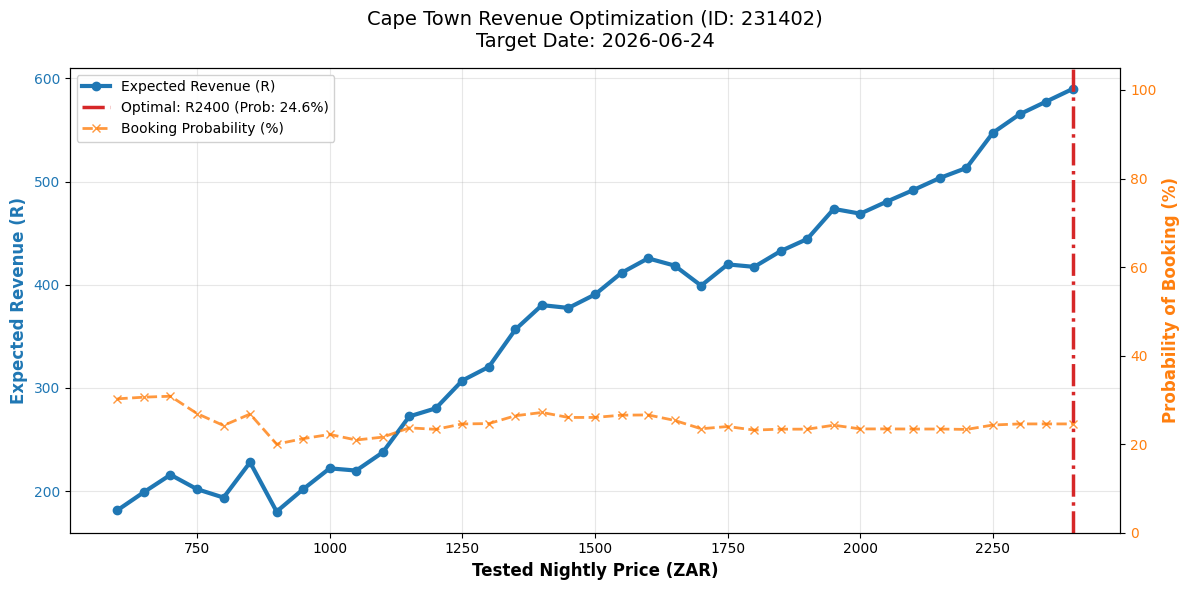

In [31]:
# 1. Grab the needed features and select a specific row 
features_needed = ['id', 'accommodates', 'bedrooms', 'room_type', 'neighbourhood_cleansed', 'proxy_base_price']
selected_listing_row = new_listings_clean[features_needed].iloc[6]

# Select Target date
target_date = pd.to_datetime("2026-6-24") 

# Extract variables
listing_id = selected_listing_row['id']
anchor_price = selected_listing_row['proxy_base_price']

# 2. ALIGNMENT & NaN PREVENTION
bedrooms_val = selected_listing_row['bedrooms']
clean_bedrooms = float(bedrooms_val) if not pd.isna(bedrooms_val) else 1.0

accommodates_val = selected_listing_row['accommodates']
clean_accommodates = float(accommodates_val) if not pd.isna(accommodates_val) else 2.0

raw_dict = {
        'price_ratio': 0, 
        'accommodates': clean_accommodates,
        'bedrooms': clean_bedrooms,
        'room_type': selected_listing_row['room_type'],
        'neighbourhood_cleansed': selected_listing_row['neighbourhood_cleansed'],
        'month': target_date.month,
        'day_of_week': target_date.dayofweek,
        'is_weekend': 1 if target_date.dayofweek >= 5 else 0,
        'review_scores_rating': selected_listing_row.get('review_scores_rating', np.nan), # Pipeline imputer handles the NaN
        'number_of_reviews': selected_listing_row.get('number_of_reviews', 0),            # 0 reviews for a new listing
        'host_is_superhost': selected_listing_row.get('host_is_superhost', 0),            # New hosts aren't superhosts
        'minimum_nights': selected_listing_row.get('minimum_nights', 1)                   # Default to 1-night minimum
    }

single_listing_raw = pd.DataFrame([raw_dict])

# 3. Run the optimization engine
optimal_price, expected_revenue, optimal_prob, prices, revenues, probabilities = optimize_daily_price(
    listing_features=single_listing_raw, 
    trained_model=model, 
    base_price=anchor_price, 
    market_median_price=anchor_price, 
    lower_bound=0.5, 
    upper_bound=2, 
    step=50
)

# 4. RESULTS OUTPUT
print(f"--- RESULTS FOR CAPE TOWN LISTING {listing_id:.0f} ---")
print(f"Target Date: {target_date.strftime('%Y-%m-%d')}")
print(f"Market Proxy Base Price: R{anchor_price:.2f}")
print("-" * 40)
print(f"RECOMMENDED OPTIMAL PRICE: R{optimal_price}")
print(f"CHANCE OF BOOKING:         {optimal_prob * 100:.2f}%") 
print(f"EXPECTED DAILY REVENUE:    R{expected_revenue:.2f}")
print("-" * 40)

# 5. PLOT THE DUAL-AXIS CURVE
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- PRIMARY AXIS: Expected Revenue ---
ax1.plot(prices, revenues, color='#1f77b4', marker='o', linestyle='-', linewidth=3, label='Expected Revenue (R)')
ax1.set_xlabel('Tested Nightly Price (ZAR)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Expected Revenue (R)', color='#1f77b4', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# --- SECONDARY AXIS: Probability ---
ax2 = ax1.twinx() 
# Plotting the booking probability trend
ax2.plot(prices, probabilities, color='#ff7f0e', marker='x', linestyle='--', alpha=0.8, linewidth=2, label='Booking Probability (%)')
ax2.set_ylabel('Probability of Booking (%)', color='#ff7f0e', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')
ax2.set_ylim(0, 105) # Keep probability scale consistent

# --- OPTIMAL PRICE LINE (Updated Label) ---
# Highlighting both the Price and the resulting Booking Probability at that price
ax1.axvline(x=optimal_price, color='#d62728', linestyle='-.', linewidth=2.5,
            label=f'Optimal: R{optimal_price} (Prob: {optimal_prob*100:.1f}%)')

# Formatting the chart
plt.title(f'Cape Town Revenue Optimization (ID: {listing_id:.0f})\nTarget Date: {target_date.strftime("%Y-%m-%d")}', fontsize=14, pad=15)

# Merging legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', framealpha=0.9)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature Importance

Top 5 Drivers of Airbnb Demand in Cape Town:
                Feature  Importance
0           price_ratio    0.196681
4     number_of_reviews    0.131328
3  review_scores_rating    0.104859
5        minimum_nights    0.083808
1          accommodates    0.052729


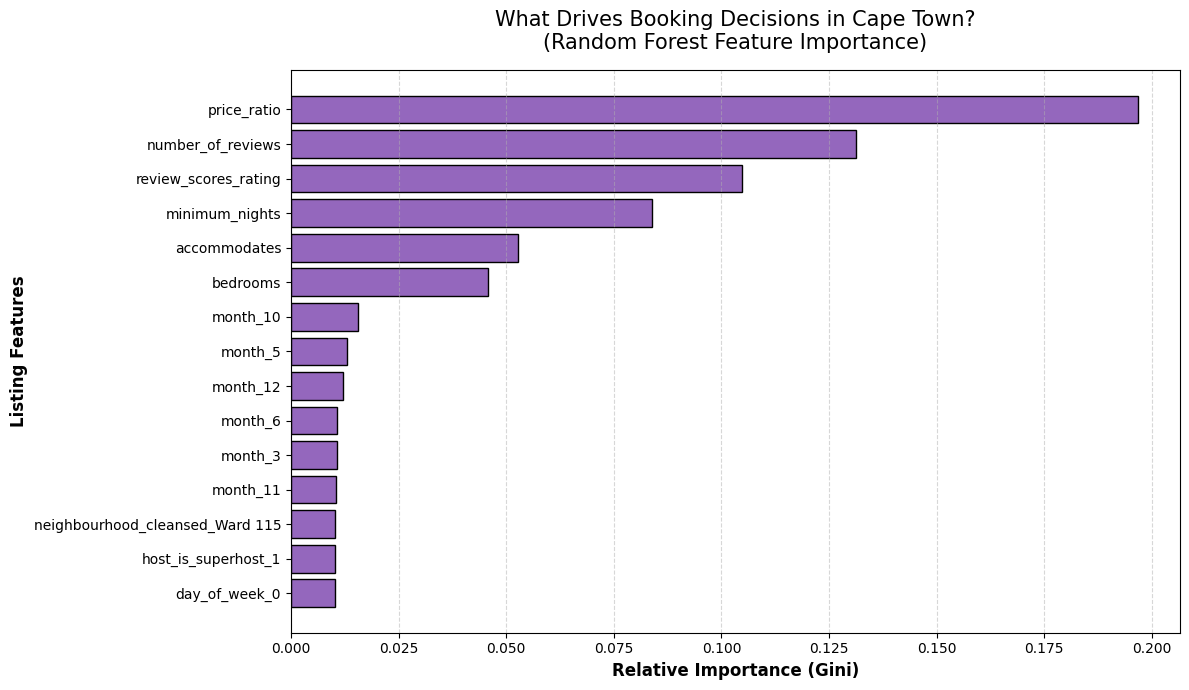

In [11]:
# 1. Isolate the two parts of your pipeline
preprocessor = model.named_steps['preprocessor']
rf_classifier = model.named_steps['classifier']

# 2. Get the new, one-hot encoded feature names from the preprocessor
# It will generate names like 'num__price' or 'cat__room_type_Private room'
feature_names = preprocessor.get_feature_names_out()

# 3. Get the Gini importance scores from the Random Forest
importances = rf_classifier.feature_importances_

# 4. Combine them into a clean Pandas DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 5. Clean up the feature names for the presentation graph (remove 'num__' and 'cat__')
importance_df['Feature'] = importance_df['Feature'].str.replace('num__', '', regex=False)
importance_df['Feature'] = importance_df['Feature'].str.replace('cat__', '', regex=False)

# Sort the top 15 most important features
top_15_features = importance_df.sort_values(by='Importance', ascending=False).head(15)

print("Top 5 Drivers of Airbnb Demand in Cape Town:")
print(top_15_features.head(5))

# ==========================================
# 6. PLOTTING THE RESULTS
# ==========================================
plt.figure(figsize=(12, 7))

# Create a horizontal bar chart
plt.barh(top_15_features['Feature'][::-1], top_15_features['Importance'][::-1], color='tab:purple', edgecolor='black')

plt.title('What Drives Booking Decisions in Cape Town?\n(Random Forest Feature Importance)', fontsize=15, pad=15)
plt.xlabel('Relative Importance (Gini)', fontsize=12, fontweight='bold')
plt.ylabel('Listing Features', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save for your presentation
plt.savefig('capetown_feature_importance.png', dpi=300)
plt.show()